In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [7]:
#Cargamos el DataFrame
df_prod = pd.read_csv('/content/senasica_prod_aguacate_limpio.csv')

#Seleccionamos los datos del estado de Michoacán
df_mich = df_prod[df_prod['Estado'] == 'Michoacán'].sort_values('Anio')

df_mich.head()

,Estado,Superficie_miles_Ha,Volumen_miles_Ton,Valor_millones_MXN,Anio
0,Michoacán,78.62738,820.22382,4505.384041,2001
3,Michoacán,81.89525,792.65890,3608.520637,2002
9,Michoacán,82.52300,800.45208,4869.582759,2003
16,Michoacán,86.54632,864.06947,5529.081638,2004
23,Michoacán,95.22282,895.09795,6963.748811,2005


In [22]:
#Dividimos los datos
X = df_mich[['Anio']].values - 2000 #Solo la cantidad de años transcurridos
y_volumen = df_mich['Volumen_miles_Ton'].values
y_superficie = df_mich['Superficie_miles_Ha'].values

# Transformación Polinomial (Grado 2: Tendencia Cuadrática)
grado = 2
poly_features = PolynomialFeatures(degree=grado)
X_poly = poly_features.fit_transform(X)

In [23]:
# Entrenar los modelos para Volumen y Superficie
modelo_vol = LinearRegression().fit(X_poly, y_volumen)
modelo_sup = LinearRegression().fit(X_poly, y_superficie)

# Generar Predicciones
y_pred_vol = modelo_vol.predict(X_poly)
y_pred_sup = modelo_sup.predict(X_poly)

# Evaluar Métricas
r2_vol = r2_score(y_volumen, y_pred_vol)
rmse_vol = np.sqrt(mean_squared_error(y_volumen, y_pred_vol))

r2_sup = r2_score(y_superficie, y_pred_sup)
rmse_sup = np.sqrt(mean_squared_error(y_superficie, y_pred_sup))

print(f"--- Métricas del Modelo (Grado {grado}) ---")
print(f"Volumen    -> R2: {r2_vol:.4f} | RMSE: {rmse_vol:.2f} miles de Ton")
print(f"Superficie -> R2: {r2_sup:.4f} | RMSE: {rmse_sup:.2f} miles de Ha")

--- Métricas del Modelo (Grado 2) ---
Volumen    -> R2: 0.9704 | RMSE: 63.21 miles de Ton
Superficie -> R2: 0.9881 | RMSE: 3.37 miles de Ha


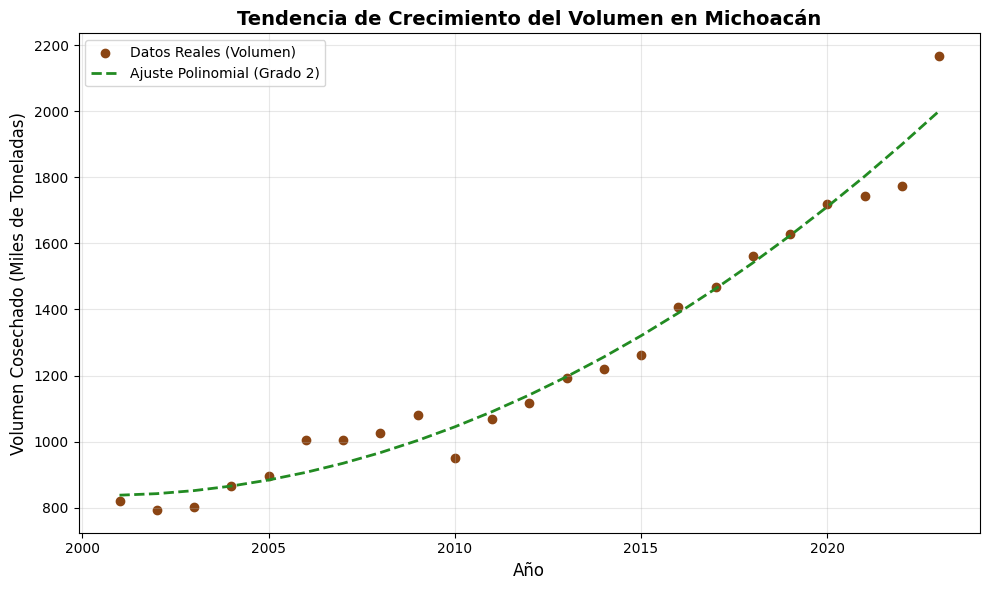

In [17]:
#Visualización del Ajuste (Ejemplo con Volumen)
plt.figure(figsize=(10, 6))
plt.scatter(df_mich['Anio'], y_volumen, color='#8B4513', label='Datos Reales (Volumen)')
plt.plot(df_mich['Anio'], y_pred_vol, color='#228B22', linewidth=2, linestyle='--', label=f'Ajuste Polinomial (Grado {grado})')

plt.title('Tendencia de Crecimiento del Volumen en Michoacán', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Volumen Cosechado (Miles de Toneladas)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

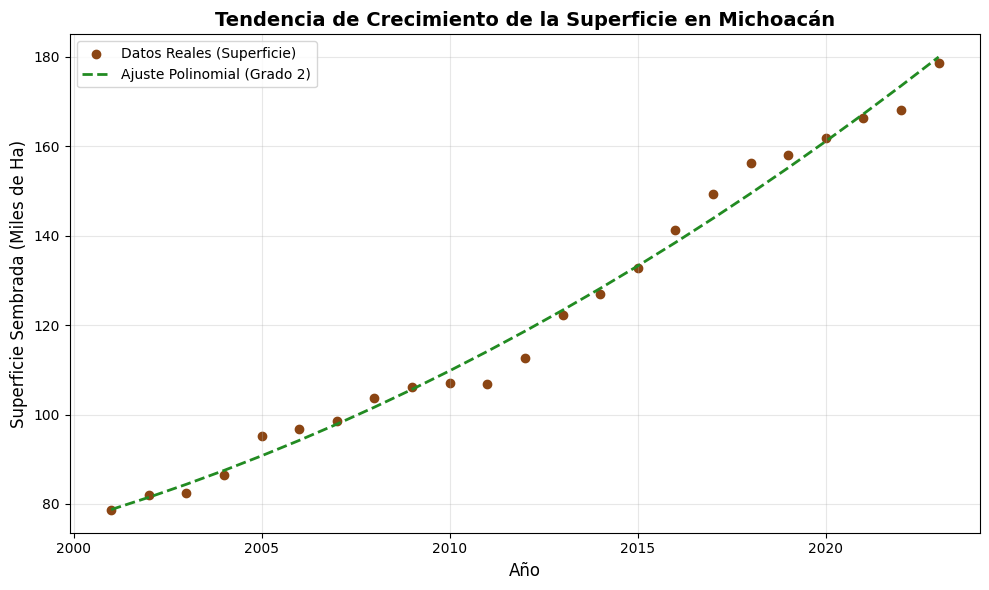

In [18]:
#Visualización del Ajuste (Ejemplo con Superficie)
plt.figure(figsize=(10, 6))
plt.scatter(df_mich['Anio'], y_superficie, color='#8B4513', label='Datos Reales (Superficie)')
plt.plot(df_mich['Anio'], y_pred_sup, color='#228B22', linewidth=2, linestyle='--', label=f'Ajuste Polinomial (Grado {grado})')

plt.title('Tendencia de Crecimiento de la Superficie en Michoacán', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Superficie Sembrada (Miles de Ha)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Transformación Polinomial (Grado 2: Tendencia Cuadrática)
grado = 3
poly_features = PolynomialFeatures(degree=grado)
X_poly = poly_features.fit_transform(X)

# Entrenar los modelos para Volumen y Superficie
modelo_vol = LinearRegression().fit(X_poly, y_volumen)
modelo_sup = LinearRegression().fit(X_poly, y_superficie)

# Generar Predicciones
y_pred_vol = modelo_vol.predict(X_poly)
y_pred_sup = modelo_sup.predict(X_poly)

# Evaluar Métricas
r2_vol = r2_score(y_volumen, y_pred_vol)
rmse_vol = np.sqrt(mean_squared_error(y_volumen, y_pred_vol))

r2_sup = r2_score(y_superficie, y_pred_sup)
rmse_sup = np.sqrt(mean_squared_error(y_superficie, y_pred_sup))

print(f"--- Métricas del Modelo (Grado {grado}) ---")
print(f"Volumen    -> R2: {r2_vol:.4f} | RMSE: {rmse_vol:.2f} miles de Ton")
print(f"Superficie -> R2: {r2_sup:.4f} | RMSE: {rmse_sup:.2f} miles de Ha")

--- Métricas del Modelo (Grado 3) ---
Volumen    -> R2: 0.9755 | RMSE: 57.59 miles de Ton
Superficie -> R2: 0.9890 | RMSE: 3.24 miles de Ha


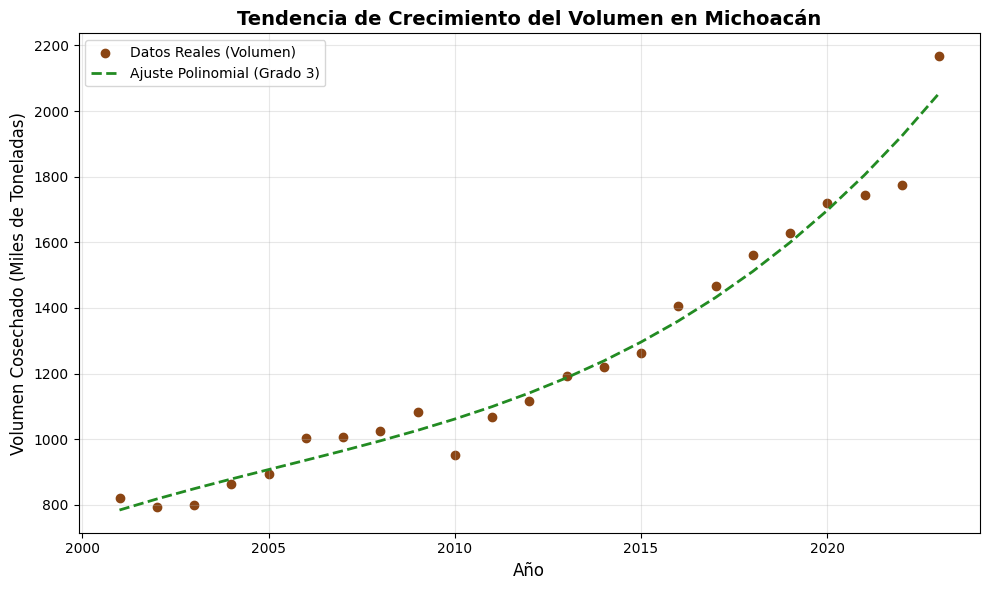

In [20]:
# Visualización del Ajuste (Ejemplo con Volumen)
plt.figure(figsize=(10, 6))
plt.scatter(df_mich['Anio'], y_volumen, color='#8B4513', label='Datos Reales (Volumen)')
plt.plot(df_mich['Anio'], y_pred_vol, color='#228B22', linewidth=2, linestyle='--', label=f'Ajuste Polinomial (Grado {grado})')

plt.title('Tendencia de Crecimiento del Volumen en Michoacán', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Volumen Cosechado (Miles de Toneladas)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

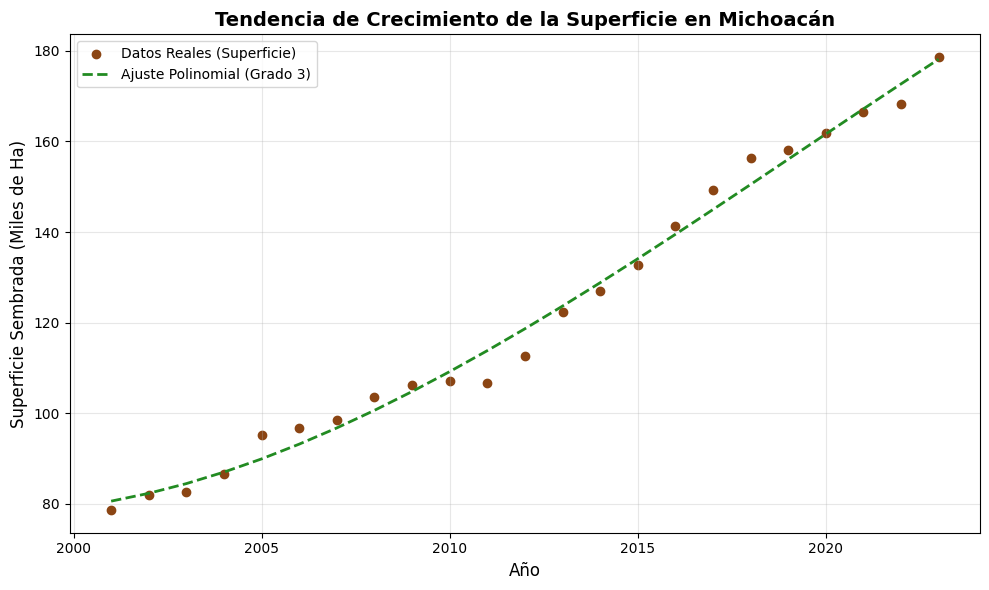

In [21]:
# Visualización del Ajuste (Ejemplo con Superficie)
plt.figure(figsize=(10, 6))
plt.scatter(df_mich['Anio'], y_superficie, color='#8B4513', label='Datos Reales (Superficie)')
plt.plot(df_mich['Anio'], y_pred_sup, color='#228B22', linewidth=2, linestyle='--', label=f'Ajuste Polinomial (Grado {grado})')

plt.title('Tendencia de Crecimiento de la Superficie en Michoacán', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Superficie Sembrada (Miles de Ha)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Predicciones a futuro (2024 y 2025)
# Desplazamos los años restando 2000 para mantener la misma escala (24 y 25)
X_futuro = np.array([[24], [25]])
X_futuro_poly = poly_features.transform(X_futuro)

# Generar los pronósticos con los modelos ya entrenados
pred_vol_futuro = modelo_vol.predict(X_futuro_poly)
pred_sup_futuro = modelo_sup.predict(X_futuro_poly)

print("--- Proyecciones a Corto Plazo (Michoacán) ---")
for i, anio in enumerate([2024, 2025]):
    print(f"Año {anio}:")
    print(f"  Superficie Estimada : {pred_sup_futuro[i]:.2f} miles de Hectáreas")
    print(f"  Volumen Estimado    : {pred_vol_futuro[i]:.2f} miles de Toneladas")

--- Proyecciones a Corto Plazo (Michoacán) ---
Año 2024:
  Superficie Estimada : 186.64 miles de Hectáreas
  Volumen Estimado    : 2106.42 miles de Toneladas
Año 2025:
  Superficie Estimada : 193.46 miles de Hectáreas
  Volumen Estimado    : 2216.74 miles de Toneladas
